### Build A Basic Chatbot With Langgraph(GRAPH API)

In [15]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [16]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]



In [17]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama-3.1-8b-instant")

c:\ML\venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 8192, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000232DE536E90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000232DE5E9650>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [18]:
llm=init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000232E0C0DAD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000232E0C0C190>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [19]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [9]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

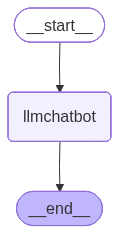

In [10]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [33]:
response=graph.invoke({"messages":"Hi"})

In [21]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [34]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm functioning properly, thanks for asking. What's on your mind, or should I suggest something?


In [35]:
print(event)

{'tool_calling_llm': {'messages': [AIMessage(content="I'm functioning properly, thanks for asking. What's on your mind, or should I suggest something?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 1750, 'total_tokens': 1772, 'completion_time': 0.040249248, 'completion_tokens_details': None, 'prompt_time': 0.098422699, 'prompt_tokens_details': None, 'queue_time': 0.008592528, 'total_time': 0.138671947}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e1041-8420-73b2-964a-5724d64fe22f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1750, 'output_tokens': 22, 'total_tokens': 1772})]}}


### Chatbot With Tool

In [36]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=3)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph/',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework built by LangChain that streamlines the creation and management of AI agent workflows. At its core, LangGraph combines large language models (LLMs) with graph-based architectures allowing developers to map, organize and optimize how AI agents interact and make decisions. By treating workflows as interconnected nodes and edges, LangGraph offers a scalable, transparent and developer-friendly way to design advanced AI systems ranging from simple chatbots to multi-agent system. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. By designing workflows, users combine multiple nodes into powerful, dynamic AI processes. * ****langgraph:**** Framework for buil

In [25]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [38]:
tools=[tool,multiply]

In [39]:
llm_with_tool=llm.bind_tools(tools)

In [40]:
llm_with_tool

RunnableBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000232E0C0DAD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000232E0C0C190>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers 

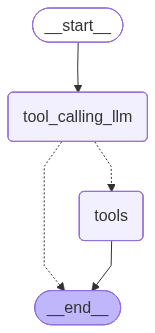

In [30]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))



In [31]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [ ]:
response['messages'][-1].content

'{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bbc.com/news/articles/cn0q2v851k9o", "title": "Amazon boss says AI will replace jobs at tech giant - BBC", "score": 0.71995544, "published_date": "Tue, 17 Jun 2025 21:31:36 GMT", "content": "Companies, especially in the tech sector, have been investing heavily in AI in recent years, spurred on by technological advances that have made it easier than ever for chatbots to create code, images and text with limited instruction.\\n\\nBut as the new tools gain traction, they have sparked warnings from some tech leaders of job losses, especially in entry-level office roles. [...] Dario Amodei, chief executive of AI-firm Anthropic, told news website Axios last month that the technology could wipe out half of entry-level white collar jobs.\\n\\nGeoffrey Hinton, whose work on AI, including at Google, has earned him the moniker \\"Godfather of AI\\", echoed those warnings on a r

In [32]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (s0jz5pbf9)
 Call ID: s0jz5pbf9
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://en.wowtale.net/2026/05/09/234037/", "title": "[Korean Startup Weekly News #117] Korea’s AI Infrastructure Boom Goes Industrial - Wowtale", "score": 0.9309621, "published_date": "Sat, 09 May 2026 13:12:58 GMT", "content": "This week’s Korean startup news highlights a broader structural shift happening across the ecosystem. AI is no longer limited to chatbots or productivity tools. Korean startups are increasingly applying AI to fact

In [ ]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (g6rrcbzyx)
 Call ID: g6rrcbzyx
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [ ]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (y5rf0ar1k)
 Call ID: y5rf0ar1k
  Args:
    query: recent ai news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bbc.com/news/articles/cn0q2v851k9o", "title": "Amazon boss says AI will replace jobs at tech giant - BBC", "score": 0.71995544, "published_date": "Tue, 17 Jun 2025 21:31:36 GMT", "content": "Companies, especially in the tech sector, have been investing heavily in AI in recent years, spurred on by technological advances that have made it easier than ever for chatbots to create code, images and text with

### ReAct Agent Architecture

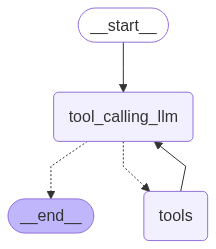

In [ ]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","
m")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (sr15kq05g)
 Call ID: sr15kq05g
  Args:
    query: recent ai news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bbc.com/news/articles/cn0q2v851k9o", "title": "Amazon boss says AI will replace jobs at tech giant - BBC", "score": 0.71995544, "published_date": "Tue, 17 Jun 2025 21:31:36 GMT", "content": "Companies, especially in the tech sector, have been investing heavily in AI in recent years, spurred on by technological advances that have made it easier than ever for chatbots to create code, images and text with

## Adding Memory In Agentic Graph

In [ ]:
response=graph.invoke({"messages":"Hello my name is KRish"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is KRish
================================== Ai Message ==================================

Nice to meet you, KRish! How are you today?


In [ ]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================
Tool Calls:
  multiply (xgm8j8jmw)
 Call ID: xgm8j8jmw
  Args:
    a: 1
    b: 0
================================= Tool Message =================================
Name: multiply

0
================================== Ai Message ==================================

I apologize for the mistake earlier. Since the tool call id "xgm8j8jmw" yielded 0, I will assume you are asking about your name again.

Unfortunately, I don't have any information about your name, as it's not provided in the conversation. Can you please provide more context or clarify what you mean by "my name"? I'll do my best to help.


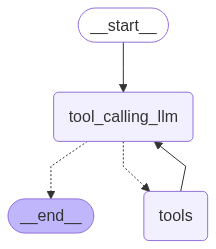

In [ ]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Krish"},config=config)

response



{'messages': [HumanMessage(content='Hi my name is Krish', additional_kwargs={}, response_metadata={}, id='e55bf5c4-e660-4919-ab56-053030ab687d'),
  AIMessage(content='Nice to meet you, Krish! Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 2193, 'total_tokens': 2216, 'completion_time': 0.033208577, 'prompt_time': 0.489441871, 'queue_time': 3.1984534190000002, 'total_time': 0.522650448}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_8b7c3a83f7', 'finish_reason': 'stop', 'logprobs': None}, id='run--b6cac6ef-4b1a-4ece-b1ed-fad73ad85355-0', usage_metadata={'input_tokens': 2193, 'output_tokens': 23, 'total_tokens': 2216})]}

In [ ]:
response['messages'][-1].content

'Nice to meet you, Krish! Is there something I can help you with or would you like to chat?'

In [ ]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Krish.


In [ ]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

Your name is Krish, right?


### Streaming

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [ ]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

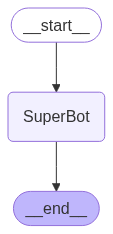

In [ ]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [ ]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='4bbd93a6-5c99-476d-af9b-2542f400b2be'),
  AIMessage(content="Hi Krish! Nice to meet you! Cricket is a great sport, isn't it? Who's your favorite cricketer or team? Do you play cricket yourself or just enjoy watching and following the game?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 20, 'total_tokens': 63, 'completion_time': 0.103689851, 'prompt_time': 0.017182506, 'queue_time': 3.3513802249999998, 'total_time': 0.120872357}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_8dc6ecaf8e', 'finish_reason': 'stop', 'logprobs': None}, id='run--46e8c88b-782a-438f-9ccc-58ab8668c0bf-0', usage_metadata={'input_tokens': 20, 'output_tokens': 43, 'total_tokens': 63})]}

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [ ]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Krish! It's great to hear that you like cricket! What's your favorite team or player in cricket?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 20, 'total_tokens': 48, 'completion_time': 0.067597787, 'prompt_time': 0.017155746, 'queue_time': 3.961062715, 'total_time': 0.084753533}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_8dc6ecaf8e', 'finish_reason': 'stop', 'logprobs': None}, id='run--dd517fd5-951c-4ba1-9af4-e5eddab1c545-0', usage_metadata={'input_tokens': 20, 'output_tokens': 28, 'total_tokens': 48})]}}


In [ ]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='2bdefe18-5571-41a9-9c62-59f9b739b6b6'), AIMessage(content="Nice to meet you, Krish! It's great to hear that you like cricket! What's your favorite team or player in cricket?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 20, 'total_tokens': 48, 'completion_time': 0.067597787, 'prompt_time': 0.017155746, 'queue_time': 3.961062715, 'total_time': 0.084753533}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_8dc6ecaf8e', 'finish_reason': 'stop', 'logprobs': None}, id='run--dd517fd5-951c-4ba1-9af4-e5eddab1c545-0', usage_metadata={'input_tokens': 20, 'output_tokens': 28, 'total_tokens': 48}), HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='12985285-9873-4723-82c7-3864b7f001e4')]}
{'messages': [HumanMessage(content='Hi,My name is Krish And I lik

In [ ]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hello Krish! Nice to meet you! It's great to know that you like cricket! Which team do you support?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 20, 'total_tokens': 45, 'completion_time': 0.041678799, 'prompt_time': 0.017140167, 'queue_time': 5.561800282, 'total_time': 0.058818966}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_8dc6ecaf8e', 'finish_reason': 'stop', 'logprobs': None}, id='run--e14c0aff-5759-4df1-9ec3-def7a3a150dd-0', usage_metadata={'input_tokens': 20, 'output_tokens': 25, 'total_tokens': 45})]}}


In [ ]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='28871637-a931-4c6d-a84b-5219d4aaf9c5'), AIMessage(content="Hello Krish! Nice to meet you! It's great to know that you like cricket! Which team do you support?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 20, 'total_tokens': 45, 'completion_time': 0.041678799, 'prompt_time': 0.017140167, 'queue_time': 5.561800282, 'total_time': 0.058818966}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_8dc6ecaf8e', 'finish_reason': 'stop', 'logprobs': None}, id='run--e14c0aff-5759-4df1-9ec3-def7a3a150dd-0', usage_metadata={'input_tokens': 20, 'output_tokens': 25, 'total_tokens': 45}), HumanMessage(content='I also like football', additional_kwargs={}, response_metadata={}, id='cdc89c65-01b1-4ccf-ab6a-48aed71fefd4')]}
{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={},

In [ ]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': 'fc9179e8-7f2a-40ea-86d8-80d86b0ab3b6', 'metadata': {'thread_id': '5'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='5cbc8727-5339-4a8a-9d63-09267608e1af')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '8108e5d5-e6eb-44a0-8057-41b3e38e8eef', 'metadata': {'thread_id': '5', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:81dc6040-44c3-d3b6-96a8-292b5d7a3caa'}, 'parent_ids': ['fc9179e8-7f2a-40ea-86d8-80d86b0ab3b6']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='Hi My name is Krish and I like to pla